In [6]:
from google.colab import userdata
import os

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

In [2]:
!ls /content

sample_data


In [1]:
!rm -rf /content/faceforensics
!rm -f /content/ff-c23.zip

In [5]:
!kaggle datasets download -d xdxd003/ff-c23

Dataset URL: https://www.kaggle.com/datasets/xdxd003/ff-c23
License(s): other
100% 16.7G/16.7G [01:39<00:00, 180MB/s]



In [6]:
!unzip -q ff-c23.zip -d /content/FaceForensics++

In [7]:
!ls /content

FaceForensics++  ff-c23.zip  sample_data


In [8]:
import os

print(os.listdir("/content/FaceForensics++"))

['FaceForensics++_C23']


In [4]:
import os

print(os.listdir("/content/FaceForensics++/FaceForensics++_C23"))

['Face2Face', 'DeepFakeDetection', 'FaceSwap', 'NeuralTextures', 'Deepfakes', 'original', 'FaceShifter', 'csv']


In [9]:
# ==========================================================
# PART 1 : LOAD FACEFORENSICS++ DATASET
# ==========================================================

import os
import random
from sklearn.model_selection import train_test_split

# -----------------------------
# DATASET PATH
# -----------------------------

DATASET_PATH = "/content/FaceForensics++/FaceForensics++_C23"

# -----------------------------
# FOLDERS
# -----------------------------

REAL_FOLDER = "original"

FAKE_FOLDERS = [
    "DeepFakeDetection",
    "Deepfakes",
    "Face2Face",
    "FaceShifter",
    "FaceSwap",
    "NeuralTextures"
]

# -----------------------------
# LIMIT VIDEOS
# -----------------------------

MAX_VIDEOS_PER_CLASS = 100

random.seed(42)

# ==========================================================
# LOAD REAL VIDEOS
# ==========================================================

real_videos = []

real_path = os.path.join(DATASET_PATH, REAL_FOLDER)

for video in sorted(os.listdir(real_path)):

    if video.endswith(".mp4"):

        real_videos.append(
            os.path.join(real_path, video)
        )

random.shuffle(real_videos)

real_videos = real_videos[:MAX_VIDEOS_PER_CLASS]

print("Real Videos :", len(real_videos))

# ==========================================================
# LOAD FAKE VIDEOS
# ==========================================================

fake_videos = []

for folder in FAKE_FOLDERS:

    folder_path = os.path.join(DATASET_PATH, folder)

    videos = []

    for video in sorted(os.listdir(folder_path)):

        if video.endswith(".mp4"):

            videos.append(
                os.path.join(folder_path, video)
            )

    random.shuffle(videos)

    videos = videos[:MAX_VIDEOS_PER_CLASS]

    fake_videos.extend(videos)

    print(folder, ":", len(videos))

print()

print("Total Fake Videos :", len(fake_videos))

# ==========================================================
# CREATE LABELS
# ==========================================================

video_paths = real_videos + fake_videos

labels = (
    [0] * len(real_videos)
    +
    [1] * len(fake_videos)
)

print()

print("Total Videos :", len(video_paths))
print("Total Labels :", len(labels))

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

train_paths, test_paths, train_labels, test_labels = train_test_split(

    video_paths,

    labels,

    test_size=0.20,

    stratify=labels,

    random_state=42

)

print()

print("Training Videos :", len(train_paths))
print("Testing Videos :", len(test_paths))

Real Videos : 100
DeepFakeDetection : 100
Deepfakes : 100
Face2Face : 100
FaceShifter : 100
FaceSwap : 100
NeuralTextures : 100

Total Fake Videos : 600

Total Videos : 700
Total Labels : 700

Training Videos : 560
Testing Videos : 140


In [10]:
# ==========================================================
# PART 2 : FRAME EXTRACTION + DATA GENERATOR
# ==========================================================

import cv2
import numpy as np
from tensorflow.keras.utils import Sequence

# -----------------------------
# PARAMETERS
# -----------------------------

IMG_SIZE = 64
MAX_FRAMES = 10
FRAME_SKIP = 5
BATCH_SIZE = 8

# ==========================================================
# FRAME EXTRACTION FUNCTION
# ==========================================================

def extract_frames(video_path):

    cap = cv2.VideoCapture(video_path)

    frames = []

    frame_count = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_count % FRAME_SKIP == 0:

            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))

            frame = frame.astype(np.float32) / 255.0

            frames.append(frame)

            if len(frames) == MAX_FRAMES:
                break

        frame_count += 1

    cap.release()

    # Padding if video has fewer frames
    while len(frames) < MAX_FRAMES:

        frames.append(
            np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
        )

    return np.array(frames)


# ==========================================================
# DATA GENERATOR
# ==========================================================

class VideoDataGenerator(Sequence):

    def __init__(self, video_paths, labels,
                 batch_size=BATCH_SIZE,
                 shuffle=True):

        self.video_paths = video_paths
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(video_paths))

        self.on_epoch_end()

    def __len__(self):

        return int(np.ceil(len(self.video_paths) / self.batch_size))

    def __getitem__(self, index):

        batch_indices = self.indices[
            index*self.batch_size:
            (index+1)*self.batch_size
        ]

        batch_videos = []
        batch_labels = []

        for i in batch_indices:

            frames = extract_frames(self.video_paths[i])

            batch_videos.append(frames)

            batch_labels.append(self.labels[i])

        return (
            np.array(batch_videos, dtype=np.float32),
            np.array(batch_labels, dtype=np.float32)
        )

    def on_epoch_end(self):

        if self.shuffle:

            np.random.shuffle(self.indices)


# ==========================================================
# CREATE GENERATORS
# ==========================================================

train_generator = VideoDataGenerator(
    train_paths,
    train_labels,
    batch_size=BATCH_SIZE
)

test_generator = VideoDataGenerator(
    test_paths,
    test_labels,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training Batches :", len(train_generator))
print("Testing Batches :", len(test_generator))


# ==========================================================
# TEST ONE BATCH
# ==========================================================

X_batch, y_batch = train_generator[0]

print()

print("Batch Shape :", X_batch.shape)
print("Labels Shape :", y_batch.shape)

Training Batches : 70
Testing Batches : 18

Batch Shape : (8, 10, 64, 64, 3)
Labels Shape : (8,)


In [11]:
# ==========================================================
# PART 3 : CNN + LSTM MODEL
# ==========================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    TimeDistributed,

    Conv2D,

    MaxPooling2D,

    Flatten,

    LSTM,

    Dense,

    Dropout,

    BatchNormalization

)

# ==========================================================
# BUILD MODEL
# ==========================================================

model = Sequential()

# -----------------------------
# CNN BLOCK 1
# -----------------------------

model.add(

    TimeDistributed(

        Conv2D(

            filters=32,

            kernel_size=(3,3),

            activation='relu'

        ),

        input_shape=(20,64,64,3)

    )

)

model.add(

    TimeDistributed(

        MaxPooling2D(pool_size=(2,2))

    )

)

model.add(

    TimeDistributed(

        BatchNormalization()

    )

)

# -----------------------------
# CNN BLOCK 2
# -----------------------------

model.add(

    TimeDistributed(

        Conv2D(

            filters=64,

            kernel_size=(3,3),

            activation='relu'

        )

    )

)

model.add(

    TimeDistributed(

        MaxPooling2D(pool_size=(2,2))

    )

)

model.add(

    TimeDistributed(

        BatchNormalization()

    )

)

# -----------------------------
# CNN BLOCK 3
# -----------------------------

model.add(

    TimeDistributed(

        Conv2D(

            filters=96,

            kernel_size=(3,3),

            activation='relu'

        )

    )

)

model.add(

    TimeDistributed(

        MaxPooling2D(pool_size=(2,2))

    )

)

# -----------------------------
# FLATTEN
# -----------------------------

model.add(

    TimeDistributed(

        Flatten()

    )

)

# -----------------------------
# LSTM
# -----------------------------

model.add(

    LSTM(

        64,

        return_sequences=False

    )

)

# -----------------------------
# DENSE
# -----------------------------

model.add(

    Dense(

        128,

        activation='relu'

    )

)

model.add(

    Dropout(

        0.5

    )

)

model.add(

    Dense(

        64,

        activation='relu'

    )

)

model.add(

    Dropout(

        0.3

    )

)

# -----------------------------
# OUTPUT
# -----------------------------

model.add(

    Dense(

        1,

        activation='sigmoid'

    )

)

# ==========================================================
# COMPILE
# ==========================================================

model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)

# ==========================================================
# MODEL SUMMARY
# ==========================================================

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 62, 62, 32) │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 31, 31, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 20, 31, 31, 32) │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 20, 29, 29, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 20, 14, 14, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 20, 14, 14, 64) │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 20, 12, 12, 96) │        55,392 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 20, 6, 6, 96)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 20, 3456)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       901,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993,185 (3.79 MB)

 Trainable params: 992,993 (3.79 MB)

 Non-trainable params: 192 (768.00 B)

In [12]:
# ==========================================================
# PART 4 : TRAIN MODEL
# ==========================================================

import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# -----------------------------
# CLASS WEIGHTS
# -----------------------------

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = {
    0: class_weights[0],
    1: class_weights[1]
}

print("Class Weights:", class_weights)

# -----------------------------
# CALLBACKS
# -----------------------------

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_deepfake_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# -----------------------------
# TRAIN
# -----------------------------

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Class Weights: {0: np.float64(3.5), 1: np.float64(0.5833333333333334)}


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7012 - loss: 0.7793
Epoch 1: val_accuracy improved from None to 0.14286, saving model to best_deepfake_model.keras

Epoch 1: finished saving model to best_deepfake_model.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 289s 4s/step - accuracy: 0.5696 - loss: 0.7605 - val_accuracy: 0.1429 - val_loss: 0.7924 - learning_rate: 0.0010
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3885 - loss: 0.7974
Epoch 2: val_accuracy improved from 0.14286 to 0.85714, saving model to best_deepfake_model.keras

Epoch 2: finished saving model to best_deepfake_model.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.4946 - loss: 0.7257 - val_accuracy: 0.8571 - val_loss: 0.6375 - learning_rate: 0.0010
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6603 - loss: 0.6500
Epoch 3: val_accuracy did not improve from 0.85714
70/70 ━━━━━━━━━━━━━━━━━━━━ 275s 4s/step - accuracy: 0.6000 - loss: 0.7040 - val_accuracy: 0.1429 - val_lo

Predicting on Test Dataset...
18/18 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step

Test Accuracy : 0.8571428571428571

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.86      1.00      0.92       120

    accuracy                           0.86       140
   macro avg       0.43      0.50      0.46       140
weighted avg       0.73      0.86      0.79       140

ROC AUC Score : 0.4666666666666667

Confusion Matrix

[[  0  20]
 [  0 120]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


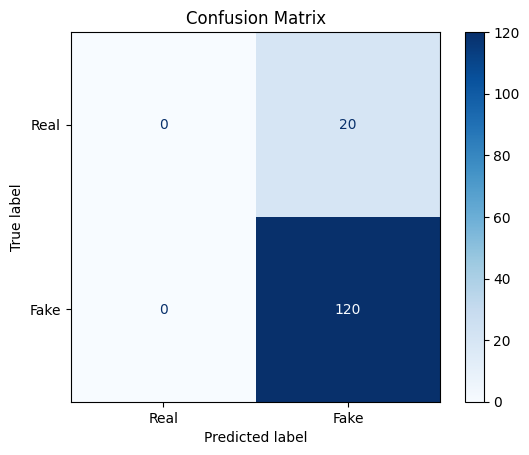

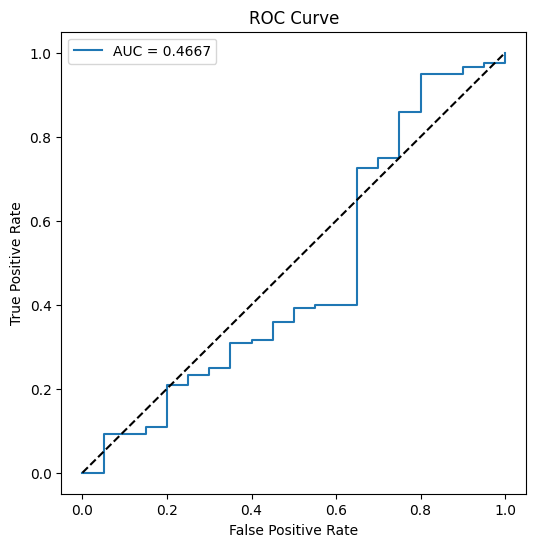

In [13]:
# ==========================================================
# PART 5 : MODEL EVALUATION
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score
)

# ----------------------------------------------------------
# PREDICT
# ----------------------------------------------------------

print("Predicting on Test Dataset...")

probabilities = model.predict(test_generator)

probabilities = probabilities.flatten()

predictions = (probabilities >= 0.5).astype(int)

# ----------------------------------------------------------
# TRUE LABELS
# ----------------------------------------------------------

true_labels = np.array(test_labels)

# ----------------------------------------------------------
# ACCURACY
# ----------------------------------------------------------

accuracy = accuracy_score(true_labels, predictions)

print("\nTest Accuracy :", accuracy)

# ----------------------------------------------------------
# CLASSIFICATION REPORT
# ----------------------------------------------------------

print("\nClassification Report\n")

print(classification_report(true_labels, predictions))

# ----------------------------------------------------------
# ROC AUC
# ----------------------------------------------------------

roc_auc = roc_auc_score(true_labels, probabilities)

print("ROC AUC Score :", roc_auc)

# ----------------------------------------------------------
# CONFUSION MATRIX
# ----------------------------------------------------------

cm = confusion_matrix(true_labels, predictions)

print("\nConfusion Matrix\n")

print(cm)

# ----------------------------------------------------------
# PLOT CONFUSION MATRIX
# ----------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# ----------------------------------------------------------
# ROC CURVE
# ----------------------------------------------------------

fpr, tpr, _ = roc_curve(true_labels, probabilities)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

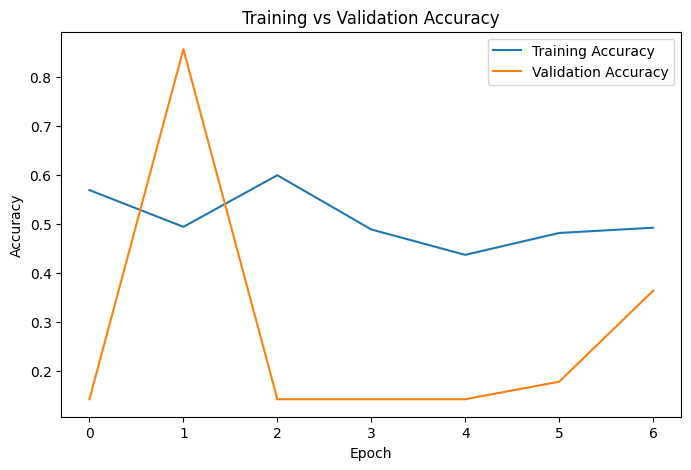

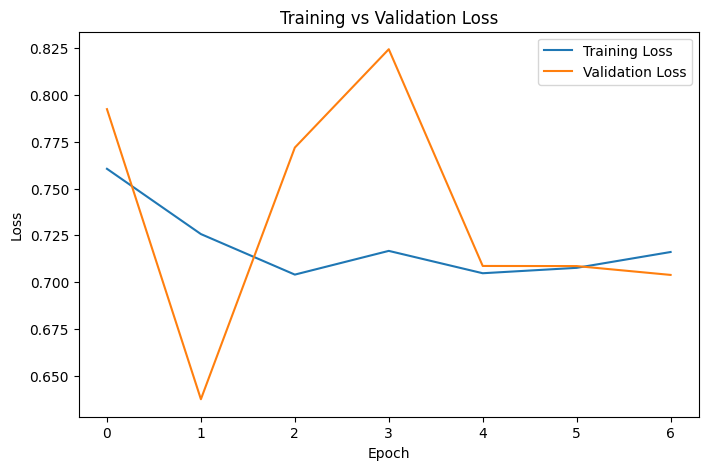

In [14]:
# ==========================================================
# TRAINING CURVES
# ==========================================================

import matplotlib.pyplot as plt

# Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

# Loss

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [18]:
# ==========================================================
# PART 6 : LOAD TRAINED MODEL
# ==========================================================

import tensorflow as tf

model = tf.keras.models.load_model("best_deepfake_model.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [19]:
# ==========================================================
# PREDICT NEW VIDEO
# ==========================================================

import cv2
import numpy as np

IMG_SIZE = 64
MAX_FRAMES = 10
FRAME_SKIP = 5


def predict_video(video_path):

    cap = cv2.VideoCapture(video_path)

    frames = []

    frame_count = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_count % FRAME_SKIP == 0:

            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = frame.astype(np.float32) / 255.0

            frames.append(frame)

            if len(frames) == MAX_FRAMES:
                break

        frame_count += 1

    cap.release()

    while len(frames) < MAX_FRAMES:

        frames.append(
            np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
        )

    video = np.expand_dims(np.array(frames), axis=0)

    probability = model.predict(video, verbose=0)[0][0]

    print("Prediction Probability :", probability)

    if probability >= 0.5:
        print("Prediction : Fake Video")
    else:
        print("Prediction : Real Video")

In [20]:
predict_video("/content/test_video.mp4")

Prediction Probability : 0.5462819
Prediction : Fake Video
